# Laptop Price Prediction

## 01 - Exploratory Data Analysis

### Objective

In this notebook, we perform an initial exploration of the laptop dataset to understand its structure, identify potential data quality issues, and gather insights before preprocessing and model development.

In [12]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
DATA_PATH = Path("../data/raw/laptop_price - dataset.csv")

In [24]:
df = pd.read_csv(DATA_PATH)

df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [25]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1275
Columns: 15


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   str    
 1   Product              1275 non-null   str    
 2   TypeName             1275 non-null   str    
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   str    
 5   CPU_Company          1275 non-null   str    
 6   CPU_Type             1275 non-null   str    
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   str    
 10  GPU_Company          1275 non-null   str    
 11  GPU_Type             1275 non-null   str    
 12  OpSys                1275 non-null   str    
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), str(10)
memory usage: 14

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Inches,1275.0,15.022902,1.429470,10.10,14.0,15.60,15.60,18.4
CPU_Frequency (GHz),1275.0,2.302980,0.503846,0.90,2.0,2.50,2.70,3.6
RAM (GB),1275.0,8.440784,5.097809,2.00,4.0,8.00,8.00,64.0
Weight (kg),1275.0,2.040525,0.669196,0.69,1.5,2.04,2.31,4.7
Price (Euro),1275.0,1134.969059,700.752504,174.00,609.0,989.00,1496.50,6099.0


In [22]:
df.describe(include=['object']).T

,count,unique,top,freq
Company,1275,19,Dell,291
Product,1275,618,XPS 13,30
TypeName,1275,6,Notebook,707
ScreenResolution,1275,40,Full HD 1920x1080,505
CPU_Company,1275,3,Intel,1214
CPU_Type,1275,93,Core i5 7200U,193
Memory,1275,39,256GB SSD,412
GPU_Company,1275,4,Intel,704
GPU_Type,1275,106,HD Graphics 620,280
OpSys,1275,9,Windows 10,1048


In [18]:
df.isna().sum()

Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

In [19]:
(df.isna().sum() / len(df)) * 100

Company                0.0
Product                0.0
TypeName               0.0
Inches                 0.0
ScreenResolution       0.0
CPU_Company            0.0
CPU_Type               0.0
CPU_Frequency (GHz)    0.0
RAM (GB)               0.0
Memory                 0.0
GPU_Company            0.0
GPU_Type               0.0
OpSys                  0.0
Weight (kg)            0.0
Price (Euro)           0.0
dtype: float64

In [20]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.columns.tolist()

['Company',
 'Product',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'CPU_Company',
 'CPU_Type',
 'CPU_Frequency (GHz)',
 'RAM (GB)',
 'Memory',
 'GPU_Company',
 'GPU_Type',
 'OpSys',
 'Weight (kg)',
 'Price (Euro)']

## Dataset Features

Let's inspect the available features before starting the analysis.

In [27]:
feature_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

feature_summary

,Data Type,Missing Values,Unique Values
Company,str,0,19
Product,str,0,618
TypeName,str,0,6
Inches,float64,0,18
ScreenResolution,str,0,40
CPU_Company,str,0,3
CPU_Type,str,0,93
CPU_Frequency (GHz),float64,0,25
RAM (GB),int64,0,9
Memory,str,0,39


In [28]:
df["Price (Euro)"].describe()

count    1275.000000
mean     1134.969059
std       700.752504
min       174.000000
25%       609.000000
50%       989.000000
75%      1496.500000
max      6099.000000
Name: Price (Euro), dtype: float64

In [29]:
df["Price (Euro)"].head()

0    1339.69
1     898.94
2     575.00
3    2537.45
4    1803.60
Name: Price (Euro), dtype: float64

In [30]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Company', 'Product', 'TypeName', 'ScreenResolution', 'CPU_Company',
       'CPU_Type', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys'],
      dtype='str')

In [31]:
for column in categorical_columns:
    print(f"{column}: {df[column].nunique()} unique values")

Company: 19 unique values
Product: 618 unique values
TypeName: 6 unique values
ScreenResolution: 40 unique values
CPU_Company: 3 unique values
CPU_Type: 93 unique values
Memory: 39 unique values
GPU_Company: 4 unique values
GPU_Type: 106 unique values
OpSys: 9 unique values


In [32]:
for column in categorical_columns:
    print("=" * 50)
    print(column)
    print(df[column].value_counts().head(10))

Company
Company
Dell       291
Lenovo     289
HP         268
Asus       152
Acer       101
MSI         54
Toshiba     48
Apple       21
Samsung      9
Razer        7
Name: count, dtype: int64
Product
Product
XPS 13                30
Inspiron 3567         25
250 G6                21
Legion Y520-15IKBN    19
Vostro 3568           19
Inspiron 5570         18
ProBook 450           18
Alienware 17          15
Inspiron 5567         14
Satellite Pro         13
Name: count, dtype: int64
TypeName
TypeName
Notebook              707
Gaming                205
Ultrabook             194
2 in 1 Convertible    117
Workstation            29
Netbook                23
Name: count, dtype: int64
ScreenResolution
ScreenResolution
Full HD 1920x1080                                505
1366x768                                         263
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         51
Full HD / Touchscreen 1920x1080                   47
1600x900         

In [33]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)',
       'Price (Euro)'],
      dtype='str')

In [34]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Inches,1275.0,15.022902,1.429470,10.10,14.0,15.60,15.60,18.4
CPU_Frequency (GHz),1275.0,2.302980,0.503846,0.90,2.0,2.50,2.70,3.6
RAM (GB),1275.0,8.440784,5.097809,2.00,4.0,8.00,8.00,64.0
Weight (kg),1275.0,2.040525,0.669196,0.69,1.5,2.04,2.31,4.7
Price (Euro),1275.0,1134.969059,700.752504,174.00,609.0,989.00,1496.50,6099.0


In [35]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## Univariate Analysis

In this section, we analyze individual features to better understand their distributions and identify potential issues before feature engineering.

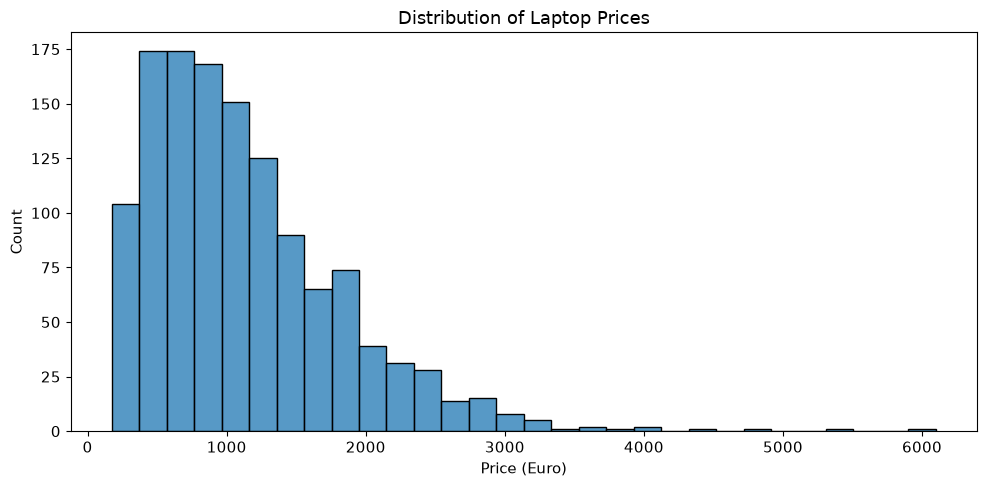

In [43]:
plt.figure(figsize=(10,5))

sns.histplot(df["Price (Euro)"], bins=30) # type: ignore

plt.title("Distribution of Laptop Prices")

plt.xlabel("Price (Euro)")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/figures/price_distribution.png",
            dpi=300,
            bbox_inches="tight")


plt.show()

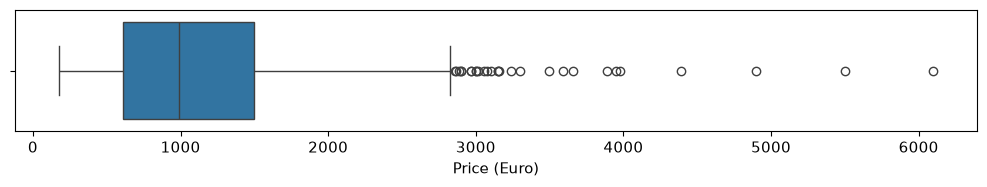

In [42]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Price (Euro)"])

plt.tight_layout()

plt.savefig("../reports/figures/price_distribution.png",
            dpi=300,
            bbox_inches="tight")


plt.show()

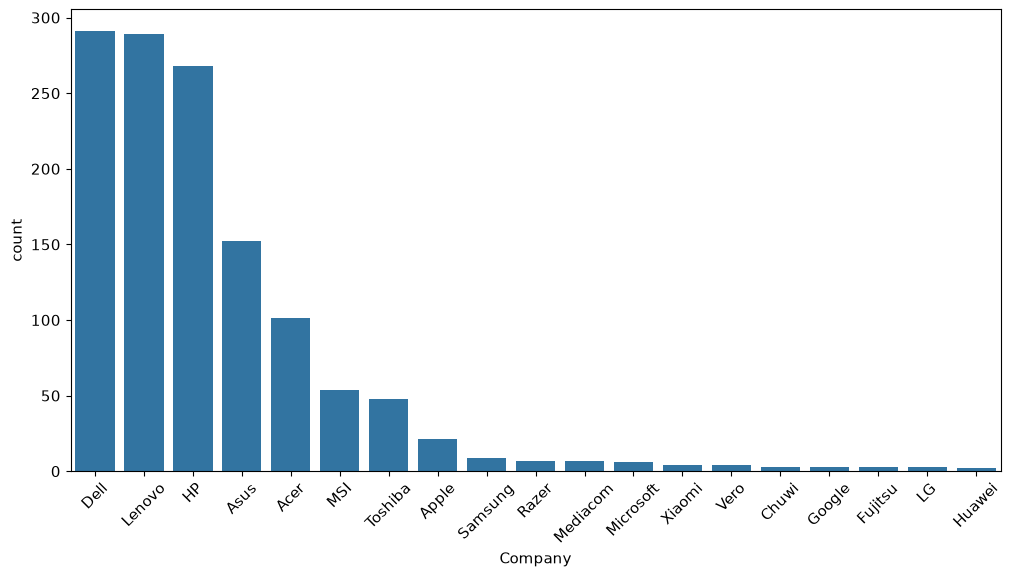

In [38]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x="Company",
              order=df["Company"].value_counts().index)

plt.xticks(rotation=45)

plt.show()

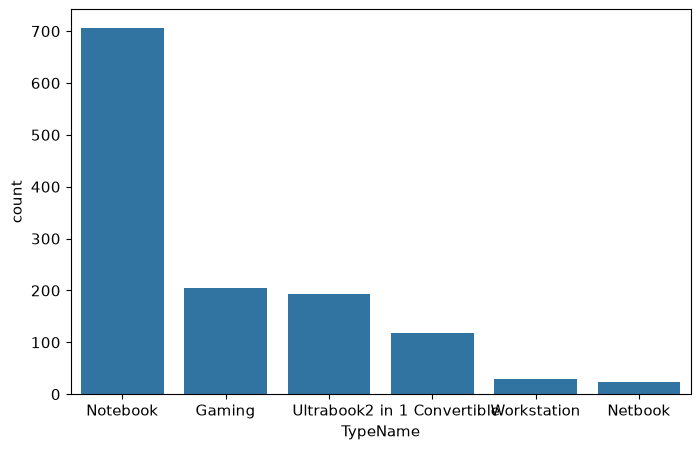

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="TypeName",
              order=df["TypeName"].value_counts().index)

plt.show()

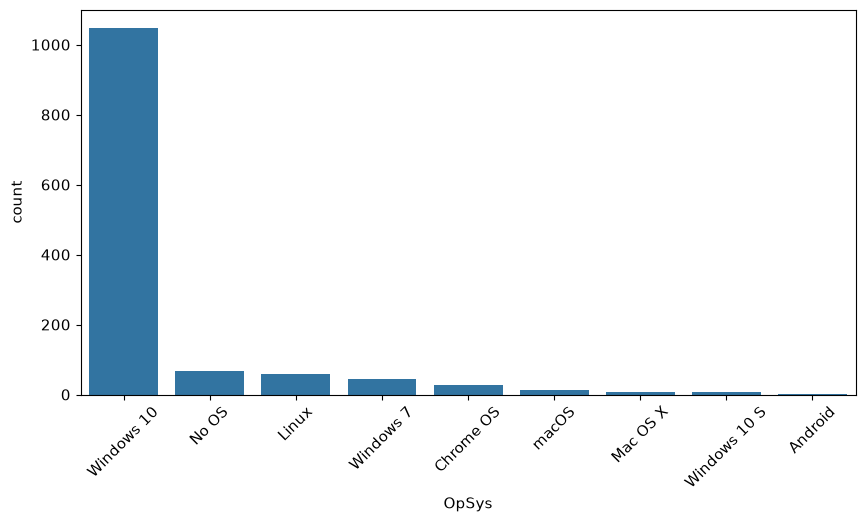

In [40]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="OpSys",
              order=df["OpSys"].value_counts().index)

plt.xticks(rotation=45)

plt.show()

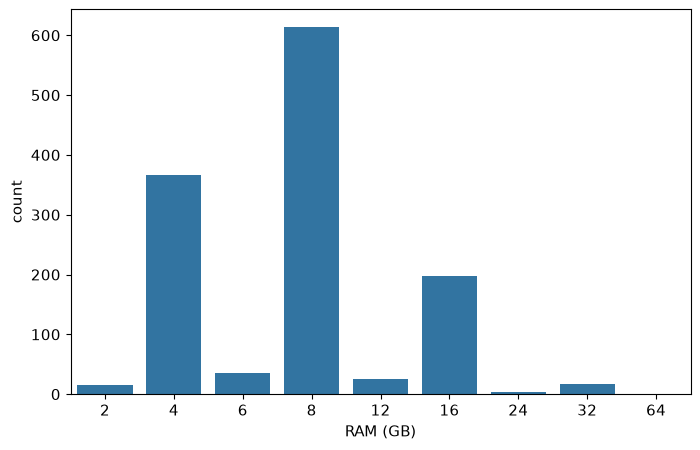

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="RAM (GB)",
              order=sorted(df["RAM (GB)"].unique()))

plt.show()

## Correlation Analysis

Explore relationships between numerical features.

In [44]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

correlation_matrix

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
Inches,1.000000,0.305037,0.241078,0.826638,0.066608
CPU_Frequency (GHz),0.305037,1.000000,0.366254,0.318649,0.428847
RAM (GB),0.241078,0.366254,1.000000,0.389370,0.740287
Weight (kg),0.826638,0.318649,0.389370,1.000000,0.211883
Price (Euro),0.066608,0.428847,0.740287,0.211883,1.000000


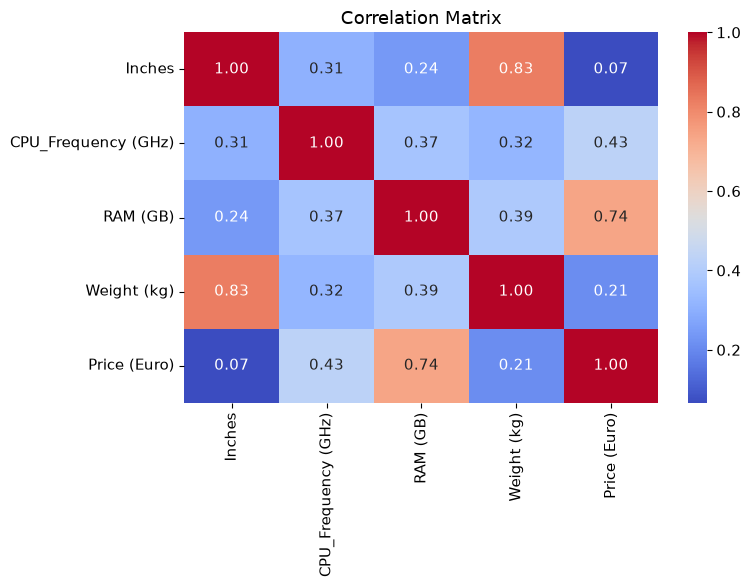

In [45]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

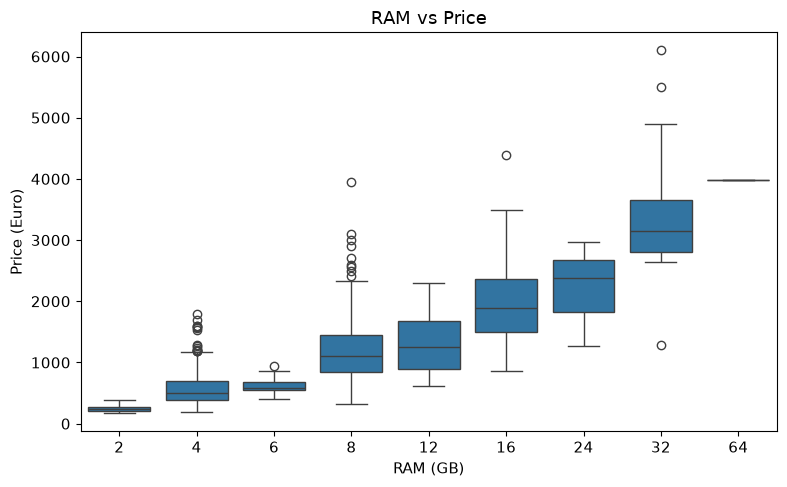

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="RAM (GB)",
    y="Price (Euro)"
)

plt.title("RAM vs Price")

plt.tight_layout()

plt.show()

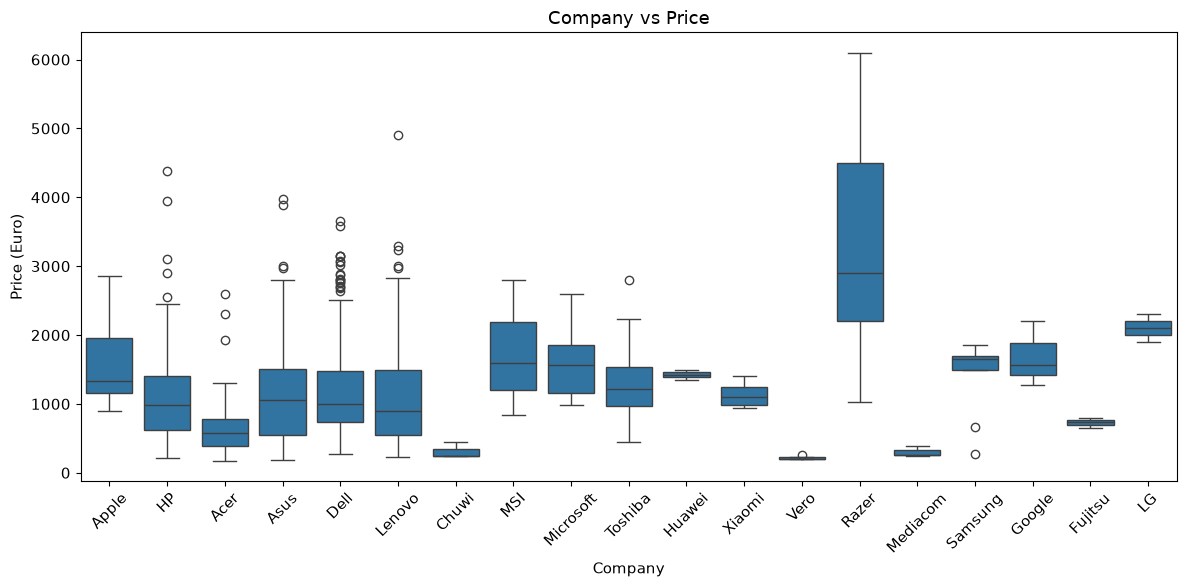

In [47]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Company",
    y="Price (Euro)"
)

plt.xticks(rotation=45)

plt.title("Company vs Price")

plt.tight_layout()

plt.show()

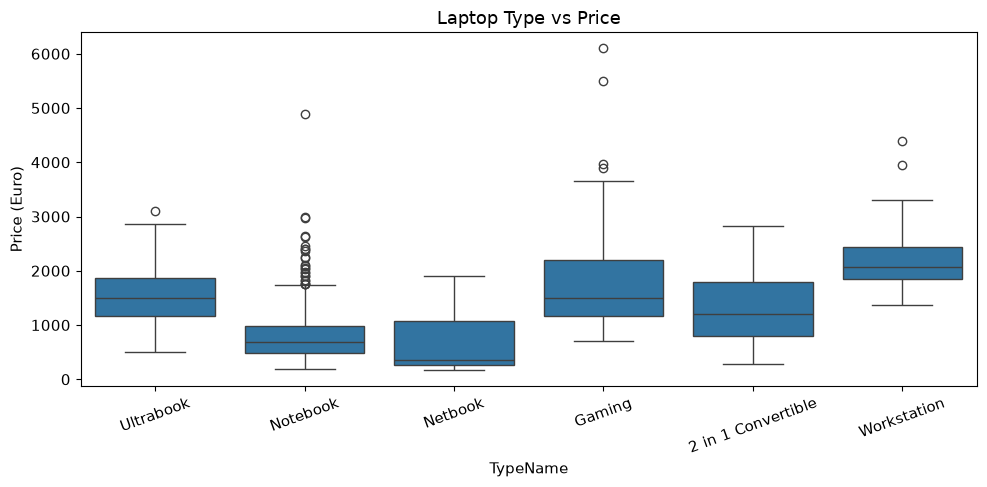

In [48]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="TypeName",
    y="Price (Euro)"
)

plt.xticks(rotation=20)

plt.title("Laptop Type vs Price")

plt.tight_layout()

plt.show()

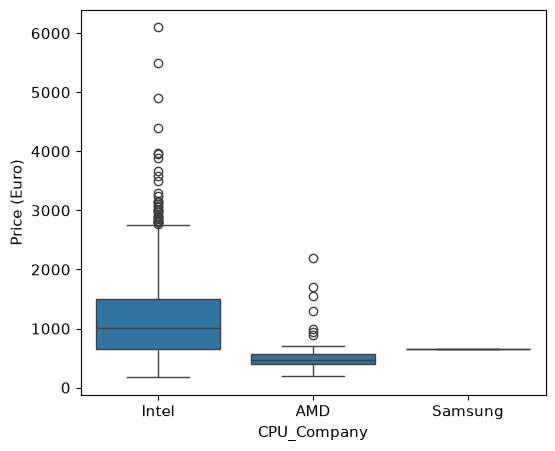

In [49]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="CPU_Company",
    y="Price (Euro)"
)

plt.show()

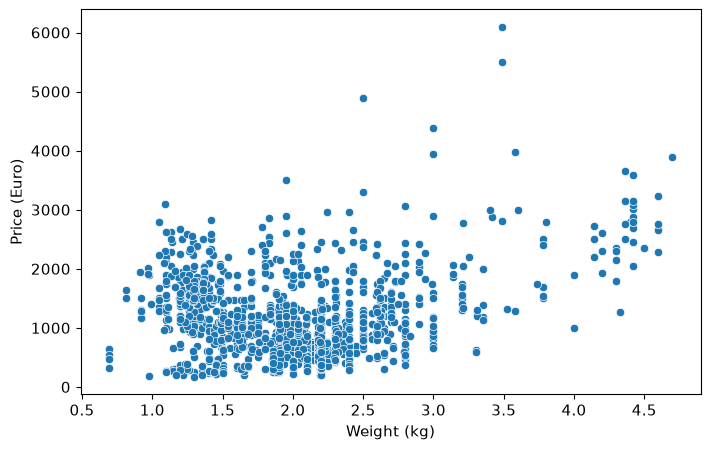

In [51]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Weight (kg)",
    y="Price (Euro)"
)

plt.show()

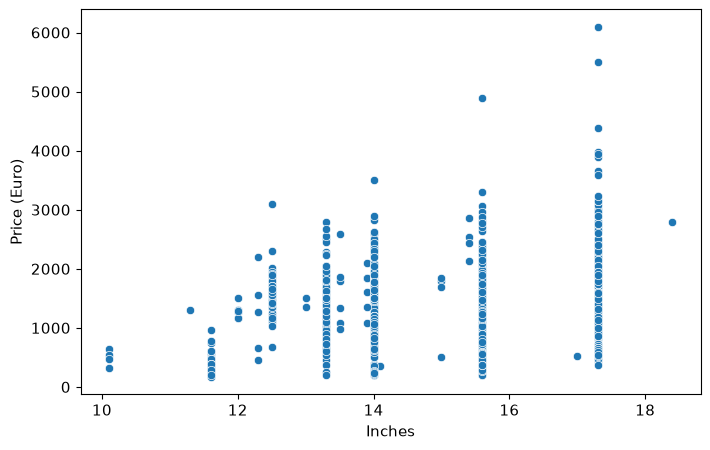

In [52]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Inches",
    y="Price (Euro)"
)

plt.show()

In [53]:
df["Memory"].value_counts()

Memory
256GB SSD                        412
1TB HDD                          215
500GB HDD                        124
512GB SSD                        114
128GB SSD +  1TB HDD              94
128GB SSD                         74
256GB SSD +  1TB HDD              73
32GB Flash Storage                36
2TB HDD                           16
512GB SSD +  1TB HDD              14
1TB SSD                           14
64GB Flash Storage                13
256GB SSD +  2TB HDD              10
256GB Flash Storage                8
1.0TB Hybrid                       7
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
256GB SSD +  256GB SSD             2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
512GB Flash Storage                2
64GB SSD                       

### Observation

The `Memory` column contains multiple pieces of information in a single feature and will require feature extraction.

In [54]:
df["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                505
1366x768                                         263
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         51
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x1440                    5
1440x900                     

### Observation

The screen resolution feature contains embedded information such as display resolution, touchscreen support, and IPS panel.

In [55]:
df["CPU_Type"].value_counts().head(20)

CPU_Type
Core i5 7200U              193
Core i7 7700HQ             147
Core i7 7500U              133
Core i3 6006U               81
Core i7 8550U               73
Core i5 8250U               72
Core i5 6200U               68
Core i7 6500U               43
Core i7 6700HQ              41
Core i3 7100U               35
Core i5 7300HQ              33
Celeron Dual Core N3350     33
Celeron Dual Core N3060     25
Core i7 6600U               18
Pentium Quad Core N4200     14
Core i5 7300U               14
Core i7 7600U               13
Core i5                     12
A9-Series 9420              12
Pentium Quad Core N3710     11
Name: count, dtype: int64

In [56]:
df["GPU_Type"].value_counts().head(20)

GPU_Type
HD Graphics 620        280
HD Graphics 520        181
UHD Graphics 620        68
GeForce GTX 1050        66
GeForce GTX 1060        48
GeForce 940MX           43
Radeon 530              41
HD Graphics 500         39
HD Graphics 400         33
GeForce GTX 1070        30
GeForce GTX 1050 Ti     28
GeForce 930MX           25
HD Graphics             23
Radeon R5 M430          20
GeForce 920MX           18
Radeon 520              17
GeForce MX150           15
HD Graphics 615         14
Radeon R7 M445          14
HD Graphics 515         13
Name: count, dtype: int64

In [57]:
df["Product"].describe()

count       1275
unique       618
top       XPS 13
freq          30
Name: Product, dtype: object

In [59]:
feature_plan = pd.DataFrame({
    "Feature": df.columns
})

feature_plan

,Feature
0,Company
1,Product
2,TypeName
3,Inches
4,ScreenResolution
5,CPU_Company
6,CPU_Type
7,CPU_Frequency (GHz)
8,RAM (GB)
9,Memory


In [61]:
feature_plan["Type"] = [
    "Categorical",
    "High Cardinality",
    "Categorical",
    "Numerical",
    "Mixed",
    "Categorical",
    "High Cardinality",
    "Numerical",
    "Numerical",
    "Mixed",
    "Categorical",
    "High Cardinality",
    "Categorical",
    "Numerical",
    "Target"
]

feature_plan["Action"] = [
    "One-Hot Encoding",
    "Evaluate Later",
    "One-Hot Encoding",
    "Keep",
    "Feature Engineering",
    "One-Hot Encoding",
    "Feature Engineering",
    "Keep",
    "Keep",
    "Feature Engineering",
    "One-Hot Encoding",
    "Feature Engineering",
    "One-Hot Encoding",
    "Keep",
    "Prediction Target"
]

feature_plan

,Feature,Type,Action
0,Company,Categorical,One-Hot Encoding
1,Product,High Cardinality,Evaluate Later
2,TypeName,Categorical,One-Hot Encoding
3,Inches,Numerical,Keep
4,ScreenResolution,Mixed,Feature Engineering
5,CPU_Company,Categorical,One-Hot Encoding
6,CPU_Type,High Cardinality,Feature Engineering
7,CPU_Frequency (GHz),Numerical,Keep
8,RAM (GB),Numerical,Keep
9,Memory,Mixed,Feature Engineering


# EDA Summary

## Key Findings

- Dataset contains no missing values.
- Dataset contains no duplicate records.
- Several categorical features require encoding.
- Memory and ScreenResolution require feature engineering.
- Product has high cardinality and will be evaluated later.
- The dataset is ready for preprocessing and feature engineering.